<a href="https://colab.research.google.com/github/mp1605/CS-4410-Intro-to-Machine-Learning-/blob/main/Homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 6

In [1]:
%pip install -q requests nltk textblob pandas matplotlib wordcloud imageio pillow

In [2]:
import nltk

nltk.download('stopwords', quiet=True, raise_on_error=True)
nltk.download('wordnet', quiet=True, raise_on_error=True)
nltk.download('punkt', quiet=True, raise_on_error=True)
# Recent NLTK versions also require this tokenizer resource.
nltk.download('punkt_tab', quiet=True, raise_on_error=True)
print('NLTK resources are ready.')

NLTK resources are ready.


## 1. Download Hamlet and create a TextBlob


In [3]:
import requests
from textblob import TextBlob

target_url = 'https://www.gutenberg.org/files/2265/2265-0.txt'
response = requests.get(target_url, timeout=60)
response.raise_for_status()
response.encoding = 'utf-8-sig'
data = response.text
assert 'hamlet' in data.lower(), 'The download does not appear to contain Hamlet.'
blob = TextBlob(data)
print(f'Downloaded {len(data):,} characters.')
print(data[:350])

Downloaded 171,696 characters.
*** START OF THE PROJECT GUTENBERG EBOOK 2265 ***


Executive Director's Notes:

In addition to the notes below, and so you will *NOT* think all
the spelling errors introduced by the printers of the time have
been corrected, here are the first few lines of Hamlet, as they
are presented herein:

  Barnardo. Who's there?
  Fran. Nay answer


## 2. Get word frequencies and remove stop words


In [4]:
from nltk.corpus import stopwords
from operator import itemgetter

stop_words = set(stopwords.words('english'))
items = blob.word_counts.items()
items = [item for item in items if item[0] not in stop_words]
# Remove punctuation-only tokens without discarding a genuine top word.
items = [item for item in items if any(character.isalpha() for character in item[0])]
sorted_items = sorted(items, key=itemgetter(1), reverse=True)
top20 = sorted_items[:20]

In [5]:
import pandas as pd

df = pd.DataFrame(top20, columns=['word', 'count'])
print(df.to_string(index=False))

  word  count
   ham    337
  lord    211
  haue    175
  king    173
 shall    107
  come    106
  thou    105
   let    104
hamlet    100
  good     98
   hor     95
   thy     90
 enter     85
    oh     81
  like     78
  well     70
   may     69
  know     69
 selfe     68
 would     68


## 3. Plot the top 20 words


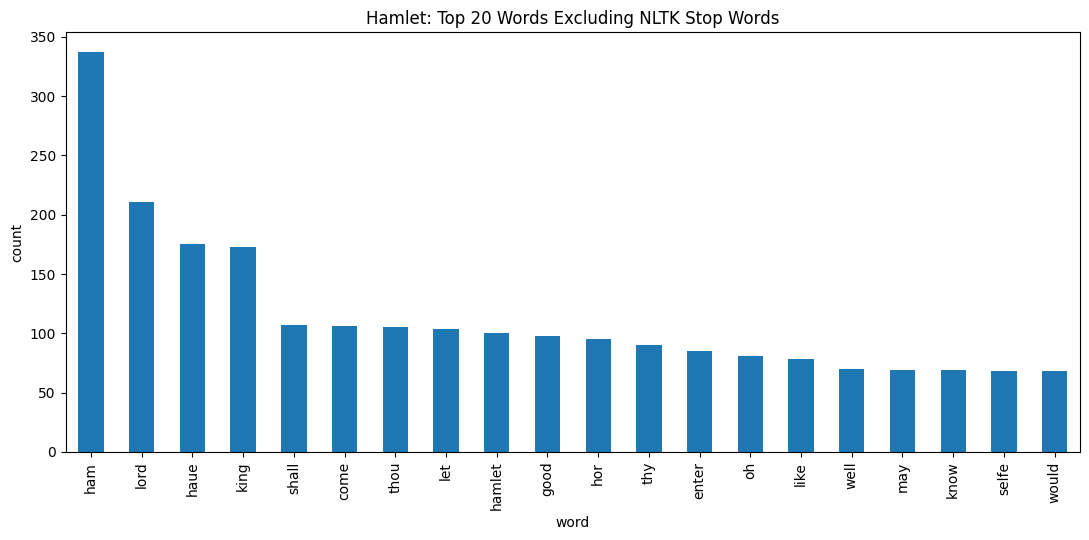

In [6]:
import matplotlib.pyplot as plt

axes = df.plot.bar(x='word', y='count', legend=False, figsize=(11, 5.5))
axes.set_title('Hamlet: Top 20 Words Excluding NLTK Stop Words')
axes.set_xlabel('word')
axes.set_ylabel('count')
plt.tight_layout()
plt.savefig('output1.png', dpi=160, bbox_inches='tight')
plt.show()

## 4. Load the supplied oval mask


In [7]:
import imageio.v3 as iio

image_file = 'https://media.cheggcdn.com/media/216/21621ee5-e80f-47f3-9145-513f2229b390/phploeBuh.png'
mask_image = iio.imread(image_file)
print('Mask shape:', mask_image.shape)

Mask shape: (592, 1024, 3)


## 5. Generate, save, and display the word cloud


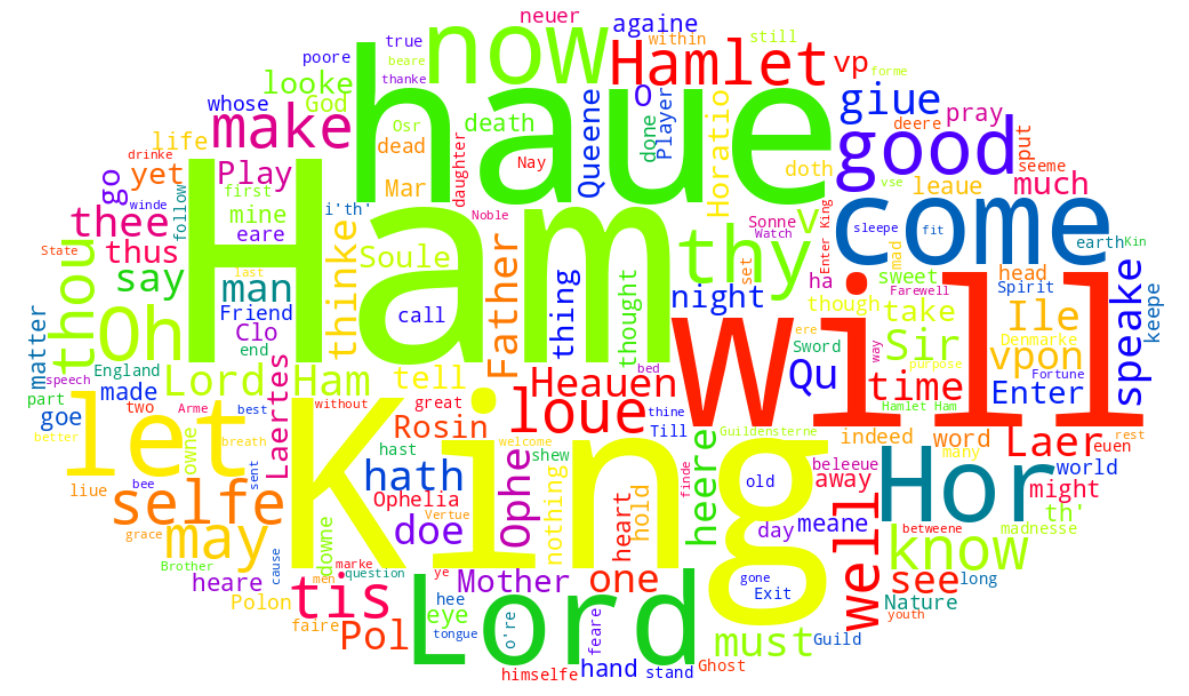

In [8]:
from wordcloud import WordCloud

# Convert prism colors to valid integer RGB values for Pillow.
# Some library combinations otherwise format negative zero as "-0".
def prism_color(word, font_size, position, orientation, random_state=None, **kwargs):
    rgba = plt.get_cmap('prism')(random_state.uniform(0, 1))
    return tuple(max(0, min(255, round(channel * 255))) for channel in rgba[:3])

wordcloud = WordCloud(
    width=1000,
    height=1000,
    colormap='prism',
    color_func=prism_color,
    mask=mask_image,
    background_color='white',
    random_state=11
)
wordcloud.generate(data)
wordcloud.to_file('Hamlet.png')

plt.figure(figsize=(12, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout()
plt.show()

## 6. Interpretation
The bar chart ranks the most frequent remaining tokens and displays their exact counts. The cloud emphasizes frequent terms with larger fonts inside an oval. Speaker abbreviations such as “ham” and “hor” are part of this edition of the play, so their presence is expected. They reflect the document's formatting as well as its dialogue.

No stemming, lemmatization, modernization of spelling, or additional stop-word removal is applied, because these would change the chapter's analysis. The screenshot is a visual reference; updated text, stop-word lists, tokenizers, or fonts can change counts and layout.

In [9]:
assert len(df) == 20
assert df['count'].is_monotonic_decreasing
assert not set(df['word']).intersection(stop_words)
assert all(any(ch.isalpha() for ch in word) for word in df['word'])
assert wordcloud.layout_, 'The word cloud is empty.'
print('Checks passed: 20 sorted non-stop-word entries and a nonempty word cloud.')
print('Most frequent remaining token:', df.iloc[0]['word'], '| Count:', df.iloc[0]['count'])
print('Saved images: output1.png and Hamlet.png')

Checks passed: 20 sorted non-stop-word entries and a nonempty word cloud.
Most frequent remaining token: ham | Count: 337
Saved images: output1.png and Hamlet.png


## Exercise 12.12 — Research: Funny Newspaper Headlines

Funny headlines illustrate how one short sentence can support multiple interpretations. I examined examples collected on Bucknell University's linguistics teaching page. These are examples from a teaching collection; the page does not establish the original newspaper and publication date for each one. The interpretations below are my analysis.

| Headline | Likely intended reading | Humorous alternative | NLP challenge |
|---|---|---|---|
| “Teacher Strikes Idle Kids” | Teacher walkouts leave pupils idle. | A teacher hits inactive children. | Parts of speech: “strikes” can be a noun or verb; “idle” can be a verb or adjective. |
| “Squad Helps Dog Bite Victim” | A squad helps someone bitten by a dog. | A squad helps a dog bite someone. | Phrase grouping: recognizing “dog bite victim” as a noun phrase. |
| “Stolen Painting Found by Tree” | A stolen painting is found near a tree. | A tree discovers the painting. | “By” can indicate location or the agent of an action. |
| “Miners Refuse to Work after Death” | Miners stop work following someone's death. | Dead miners refuse to work. | Missing context: whose death is being described? |

**Challenges identified:** word-sense ambiguity, uncertain grammatical roles, multiple sentence structures, omitted words, unclear references, and dependence on real-world knowledge. Headline compression removes clues that a full sentence or article could provide. An NLP system needs context and grammatical relationships, not just isolated word definitions, to select a plausible interpretation.

**Research source:** [Bucknell University — Syntactically Ambiguous Headlines](https://www.departments.bucknell.edu/linguistics/synhead.html).